Input records: 719603
Unique domains: 19
Duplicate rows by link + publication_date: 0
Unique categories: 305
Min publication date: 0000-00-00 00:00:00
Max publication date: 23/12/24 08:15 (GMT+7)
Rows with year < 2005: 2452
Maximum description word count: 1320
Minimum description word count: 1
Average description word count: 41.26
Description word count p50: 38.0
Description word count p90: 63.0
Description word count p99: 93.0
Description word count p5: 21.0
number of records in year 0: 79
number of records in year 1901: 2
number of records in year 1970: 31
number of records in year 1998: 1
number of records in year 1999: 6
number of records in year 2000: 14
number of records in year 2001: 290
number of records in year 2002: 266
number of records in year 2003: 223
number of records in year 2004: 290
number of records in year 2005: 1250
number of records in year 2006: 1027
number of records in year 2007: 1996
number of records in year 2008: 5673
number of records in year 2009: 13671
nu

In [1]:
from News.EDA_raw_news import add_description_word_count
from News.EDA_raw_news import parse_publication_date_series
from News.EDA_raw_news import build_year_before_2010_rows
from News.EDA_raw_news import build_unique_value_counts
from News.EDA_raw_news import INPUT_PATH
from News.EDA_raw_news import load_input_data
from News.EDA_raw_news import NULL_LIKE_VALUES
from News.EDA_raw_news import normalize_text_columns
from News.EDA_raw_news import TEXT_COLUMNS
from __future__ import annotations
import ast
import pandas as pd


def normalize_domain_column(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    normalize_domain = out.copy()
    domain = normalize_domain["domain"].astype("string").str.lower()
    domain = domain.mask(domain.isna() | domain.fillna("").isin(NULL_LIKE_VALUES))
    domain = domain.str.replace(r"^https?://", "", regex=True)
    domain = domain.str.replace(r"^www\.", "", regex=True)
    domain = domain.str.split("/", n=1).str[0]
    domain = domain.str.split("?", n=1).str[0]
    domain = domain.str.split("#", n=1).str[0]
    normalize_domain["domain"] = domain.mask(domain.fillna("").eq("")).astype("string")
    return out, normalize_domain


def parse_dict_like_keywords(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    out = df.copy()
    original_keywords = out["keywords"].astype("string")

    def parse_keyword_value(raw: object) -> object:
        if pd.isna(raw):
            return pd.NA

        if isinstance(raw, dict):
            keys = [str(key) for key in raw.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA

        text = str(raw)
        if text == "" or text.lower() in NULL_LIKE_VALUES:
            return pd.NA
        if not (text.startswith("{") and text.endswith("}")):
            return text

        try:
            parsed = ast.literal_eval(text)
        except Exception:
            return text

        if isinstance(parsed, dict):
            keys = [str(key) for key in parsed.keys() if str(key) != ""]
            return ", ".join(keys) if keys else pd.NA
        return text

    out["keywords"] = out["keywords"].apply(parse_keyword_value).astype("string")
    parsed_mask = original_keywords.ne(out["keywords"].astype("string"))
    parsed_keyword_rows = out.loc[parsed_mask].copy().reset_index(drop=True)
    return out, parsed_keyword_rows


def build_clean_news(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    raw_publication_date = out["publication_date"].astype("string").str.strip()
    invalid_publication_date_mask = (
        raw_publication_date.isna()
        | raw_publication_date.fillna("").str.lower().isin(NULL_LIKE_VALUES)
        | raw_publication_date.eq("0000-00-00 00:00:00")
    )
    out["publication_date"] = parse_publication_date_series(out["publication_date"])
    out = out.loc[~invalid_publication_date_mask & out["publication_date"].notna()].copy()
    year_before_2010_rows = build_year_before_2010_rows(out)
    out = out.drop(index=year_before_2010_rows.index).copy()
    out = add_description_word_count(out)
    out = out.loc[out["description_word_count"].ge(5)].copy()
    out = out.drop_duplicates(subset=["link", "publication_date"], keep="first").copy()
    out = out.sort_values(["publication_date", "link"], kind="mergesort").reset_index(drop=True)

    _, normalize_domain = normalize_domain_column(out)
    normalized_keywords, parsed_keyword_rows = parse_dict_like_keywords(out)

    clean_news = pd.DataFrame(
        {
            "publication_date": out["publication_date"],
            "year": out["year"],
            "domain_norm": normalize_domain["domain"].astype("string"),
            "category": out["category"],
            "title": out["title"],
            "description": out["description"],
            "keywords_norm": normalized_keywords["keywords"].astype("string"),
        }
    )
    return clean_news.reset_index(drop=True)


def main() -> None:
    raw_df = load_input_data(INPUT_PATH)
    normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
    input_rows = len(raw_df)
    prepared_df = normalized_df.copy()
    # normalized_keywords, parsed_keyword_rows = parse_dict_like_keywords(normalized_df)
    category_counts = build_unique_value_counts(prepared_df, "category")
    domain_counts = build_unique_value_counts(prepared_df, "domain")
    clean_news_df = build_clean_news(prepared_df)

    print("Input rows:", input_rows)
    print("Clean news rows:", len(clean_news_df))
    # print("Parsed keyword rows:", len(parsed_keyword_rows))

if __name__ == "__main__":
    main()




Input rows: 719603
Clean news rows: 675998


In [13]:
from News.EDA_raw_news import add_description_word_count
from News.EDA_raw_news import parse_publication_date_series
from News.EDA_raw_news import build_year_before_2010_rows
from News.EDA_raw_news import build_unique_value_counts
from News.EDA_raw_news import INPUT_PATH
from News.EDA_raw_news import load_input_data
from News.EDA_raw_news import NULL_LIKE_VALUES
from News.EDA_raw_news import normalize_text_columns
from News.EDA_raw_news import TEXT_COLUMNS
from __future__ import annotations
import ast
import pandas as pd

raw_df = load_input_data(INPUT_PATH)
normalized_df = normalize_text_columns(raw_df, TEXT_COLUMNS)
prepared_df = normalized_df.copy()
clean_news_df = build_clean_news(prepared_df)
df = clean_news_df.copy()

description_series = df["description"].astype("string").str.strip()
missing_description_mask = (
    description_series.isna()
    | description_series.fillna("").str.lower().isin(NULL_LIKE_VALUES)
)

domain_summary = (
    df.assign(_missing_description=missing_description_mask)
      .groupby("domain_norm", dropna=False)
      .agg(
          Row_count=("domain_norm", "size"),
          **{"Missing description": ("_missing_description", "sum")},
      )
      .reset_index()
      .rename(columns={"domain_norm": "Domain"})
      .sort_values(["Row_count", "Domain"], ascending=[False, True], kind="mergesort")
      .reset_index(drop=True)
)

domain_summary.insert(0, "Index", range(1, len(domain_summary) + 1))

domain_summary["Missing description"] = domain_summary["Missing description"].fillna(0).astype(int)
domain_summary["Row_count"] = domain_summary["Row_count"].fillna(0).astype(int)

domain_summary

,Index,Domain,Row_count,Missing description
0,1,vietstock.vn,289092,0
1,2,baodautu.vn,123385,0
2,3,thanhtra.com.vn,111631,0
3,4,diendandoanhnghiep.vn,91066,0
4,5,doanhnhansaigon.vn,23174,0
5,6,baochinhphu.vn,12547,0
6,7,vietnamnet.vn,8508,0
7,8,thanhnien.vn,4065,0
8,9,dantri.com.vn,3903,0
9,10,vietnamfinance.vn,3235,0


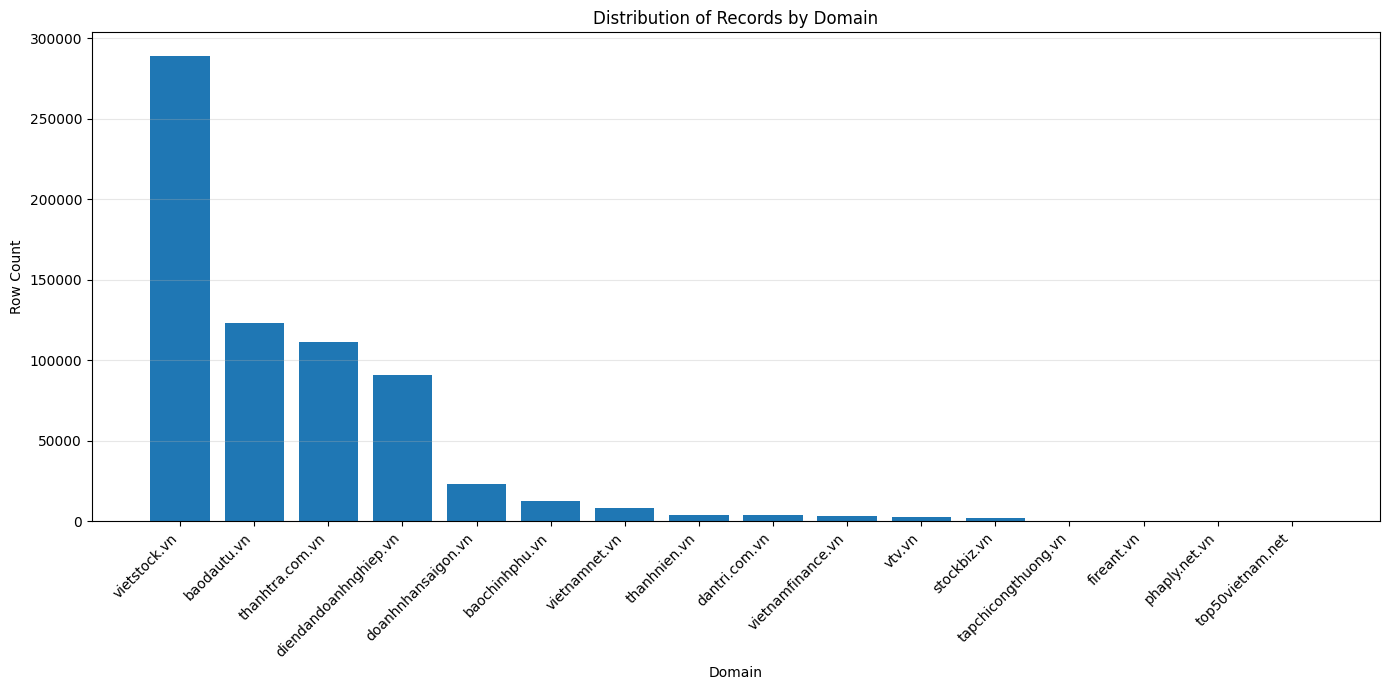

In [14]:
import matplotlib.pyplot as plt

plot_df = domain_summary.copy()

plt.figure(figsize=(14, 7))
plt.bar(plot_df["Domain"], plot_df["Row_count"])

plt.title("Distribution of Records by Domain")
plt.xlabel("Domain")
plt.ylabel("Row Count")

plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

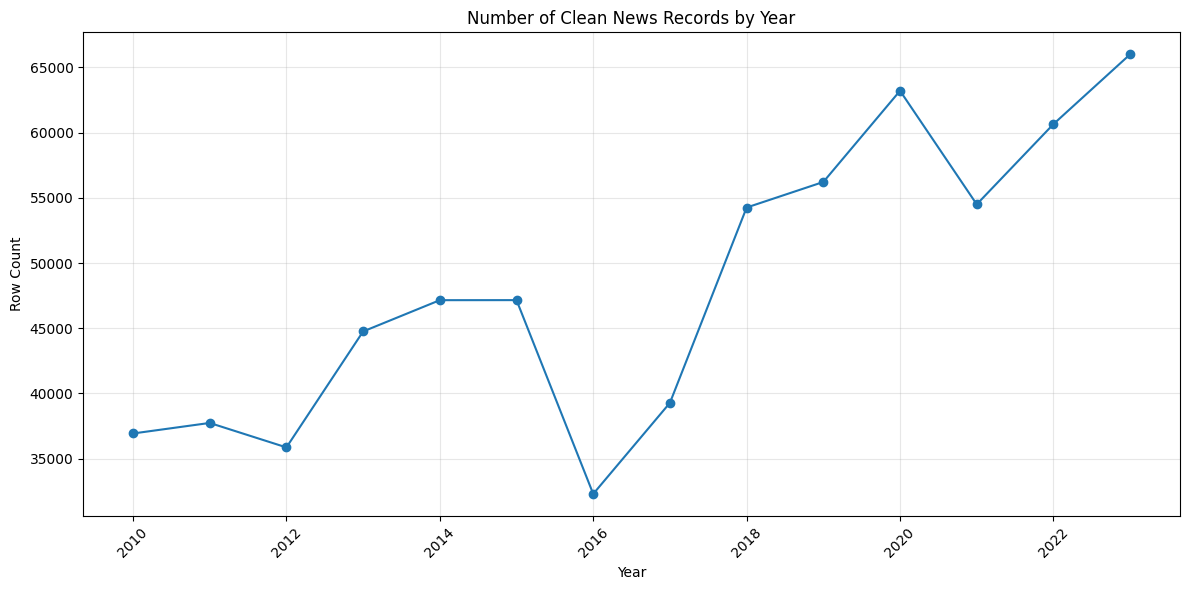

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator

plot_df = clean_news_df.copy()
plot_df["year"] = pd.to_numeric(plot_df["year"], errors="coerce").astype("Int64")

year_counts = (
    plot_df.loc[plot_df["year"].notna()]
    .groupby("year")
    .size()
    .reset_index(name="row_count")
    .sort_values("year")
    .reset_index(drop=True)
)

plt.figure(figsize=(12, 6))
plt.plot(year_counts["year"], year_counts["row_count"], marker="o")

plt.title("Number of Clean News Records by Year")
plt.xlabel("Year")
plt.ylabel("Row Count")

ax = plt.gca()
ax.xaxis.set_major_locator(MultipleLocator(2))  
plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
df = pd.read_parquet("dataset_news.parquet")
df["year"] = df["publication_date"].dt.year.astype("Int64")
df[["publication_date", "year"]].to_csv("all.csv", index=False)

ValueError: time data "2022-08-07T19:02:00+07:00" doesn't match format "%Y-%m-%d %H:%M:%S.%f", at position 263323. You might want to try:
    - passing `format` if your strings have a consistent format;
    - passing `format='ISO8601'` if your strings are all ISO8601 but not necessarily in exactly the same format;
    - passing `format='mixed'`, and the format will be inferred for each element individually. You might want to use `dayfirst` alongside this.